<a href="https://colab.research.google.com/github/LinaAbufaraha/NLP_POS_Tagger/blob/main/pos_tagging_project_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ahmadfahoum/en-universal-dev/en-universal-dev.conll
/kaggle/input/datasets/ahmadfahoum/en-universal-train/en-universal-train.conll


# ENCS5342 Final Project

## Track 1: Part-of-Speech (POS) Tagging on the English Penn Treebank

### Team Members

- Ahmad Fahoum (1213432)
- Rahmaa Dalane (1212522)
- Lina AbuFarha (1211968)

# 1. Abstract

This project presents a Part-of-Speech (POS) tagging system for English using the Penn Treebank corpus. The goal is to predict a joint POS tag that combines both coarse-grained and fine-grained grammatical categories for each token. We implement and compare multiple approaches, including a baseline model and a neural network-based model, and evaluate their performance using accuracy, precision, recall, and F1-score metrics. The project includes data preprocessing, model training, evaluation, and error analysis on the provided training and development datasets.

# 2. Introduction

Part-of-Speech (POS) tagging is one of the fundamental tasks in Natural Language Processing (NLP). It involves assigning a grammatical category to each word in a sentence based on its meaning and context. POS tagging plays an important role in many NLP applications such as information retrieval, machine translation, named entity recognition, and text understanding.

In this project, we build a POS tagger using the English Penn Treebank dataset. The target label is a joint tag created by combining the coarse-grained POS tag and the fine-grained POS tag. We investigate different approaches for POS tagging and compare their performance using standard classification metrics.

# 3. Prior & Related Work

Part-of-Speech tagging has been extensively studied in NLP. Traditional approaches include rule-based systems, Hidden Markov Models (HMMs), Maximum Entropy models, and Conditional Random Fields (CRFs). More recently, neural network architectures such as Recurrent Neural Networks (RNNs), Long Short-Term Memory (LSTM) networks, and Transformer-based models have achieved strong performance on sequence labeling tasks.

In this project, we explore and compare different POS tagging approaches and analyze their effectiveness on the English Penn Treebank corpus.

### Related Paper

Huang, Z., Xu, W., and Yu, K. (2015) proposed a Bidirectional LSTM-CRF architecture for sequence labeling tasks such as Part-of-Speech tagging, Named Entity Recognition, and Chunking. Their model combines the contextual representation power of BiLSTMs with structured prediction using Conditional Random Fields (CRFs). The study demonstrated that neural sequence models can achieve strong performance without extensive handcrafted features.

Our project differs from this work by using a simpler Bidirectional LSTM architecture without a CRF layer. The goal is to build and evaluate a POS tagger from scratch while maintaining a manageable level of complexity suitable for the course project.

# 4. Data

In [ ]:
# ============================================================
# 4.1 Import Libraries and Set File Paths
# ============================================================

# Import libraries for data handling and analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import warnings

# Ignore unnecessary warnings
warnings.filterwarnings("ignore")

# Define dataset file paths
TRAIN_PATH = "/kaggle/input/datasets/ahmadfahoum/en-universal-train/en-universal-train.conll"
DEV_PATH = "/kaggle/input/datasets/ahmadfahoum/en-universal-dev/en-universal-dev.conll"

# Confirm that libraries and paths are ready
print("Libraries loaded successfully.")

Libraries loaded successfully.


## 4.1 Reading CoNLL Files

In [ ]:
# ============================================================
# 4.2 Define Function to Read CoNLL Files
# ============================================================

def read_conll_file(file_path):
    """
    Reads a CoNLL formatted file and returns a list of sentences.
    Each sentence is represented as a list of token dictionaries.
    """

    # List to store all sentences
    sentences = []

    # Temporary list to store tokens of the current sentence
    current_sentence = []

    # Open and read the file line by line
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:

            # Remove extra spaces and newline characters
            line = line.strip()

            # Empty line means the end of a sentence
            if line == "":
                if current_sentence:
                    sentences.append(current_sentence)
                    current_sentence = []
                continue

            # Split the line by tab because CoNLL format is tab-separated
            parts = line.split("\t")

            # Use only valid token lines with enough columns
            if len(parts) >= 5:

                # Column 2: word form
                word = parts[1]

                # Column 4: coarse-grained POS tag
                cpos = parts[3]

                # Column 5: fine-grained POS tag
                fpos = parts[4]

                # Create the required joint POS tag
                joint_tag = f"{cpos}-{fpos}"

                # Store token information
                current_sentence.append({
                    "word": word,
                    "cpos": cpos,
                    "fpos": fpos,
                    "joint_tag": joint_tag
                })

    # Add the last sentence if the file does not end with an empty line
    if current_sentence:
        sentences.append(current_sentence)

    return sentences

## 4.2 Loading the Training and Development Sets

In [ ]:
# ============================================================
# 4.3 Load Training and Development Data
# ============================================================

# Read the training file
train_sentences = read_conll_file(TRAIN_PATH)

# Read the development file
dev_sentences = read_conll_file(DEV_PATH)

# Print the number of sentences in each dataset
print("Train sentences:", len(train_sentences))
print("Dev sentences:", len(dev_sentences))

Train sentences: 37840
Dev sentences: 1992


## 4.3 Dataset Statistics

In [ ]:
# ============================================================
# 4.4 Calculate Basic Dataset Statistics
# ============================================================

# Count total tokens in training data
train_tokens = sum(len(sentence) for sentence in train_sentences)

# Count total tokens in development data
dev_tokens = sum(len(sentence) for sentence in dev_sentences)

# Print dataset statistics
print("Training Sentences :", len(train_sentences))
print("Training Tokens    :", train_tokens)

print()

print("Development Sentences :", len(dev_sentences))
print("Development Tokens    :", dev_tokens)

Training Sentences : 37840
Training Tokens    : 902902

Development Sentences : 1992
Development Tokens    : 47126


## 4.4 Sentence Length Analysis

In [ ]:
# ============================================================
# 4.5 Analyze Sentence Lengths
# ============================================================

# Compute sentence lengths
train_lengths = [len(sentence) for sentence in train_sentences]
dev_lengths = [len(sentence) for sentence in dev_sentences]

# Display statistics
print("Training Set")

print("Minimum Length :", min(train_lengths))
print("Maximum Length :", max(train_lengths))
print("Average Length :", round(np.mean(train_lengths), 2))

print()

print("Development Set")

print("Minimum Length :", min(dev_lengths))
print("Maximum Length :", max(dev_lengths))
print("Average Length :", round(np.mean(dev_lengths), 2))

Training Set
Minimum Length : 1
Maximum Length : 141
Average Length : 23.86

Development Set
Minimum Length : 1
Maximum Length : 79
Average Length : 23.66


## 4.5 POS Tag Distribution Analysis

In [ ]:
# ============================================================
# 4.6 Analyze Joint POS Tag Distribution
# ============================================================

# Collect all joint tags from training data
all_tags = []

for sentence in train_sentences:
    for token in sentence:
        all_tags.append(token["joint_tag"])

# Count tag frequencies
tag_counter = Counter(all_tags)

# Display dataset information
print("Number of Unique Joint POS Tags:", len(tag_counter))

print("\nTop 20 Most Frequent Joint POS Tags:\n")

for tag, count in tag_counter.most_common(20):
    print(f"{tag:<20} {count}")

Number of Unique Joint POS Tags: 45

Top 20 Most Frequent Joint POS Tags:

NOUN-NN              126176
ADP-IN               102515
NOUN-NNP             87033
DET-DT               77723
ADJ-JJ               58227
NOUN-NNS             56900
.-,                  46317
.-.                  37506
NUM-CD               34775
ADV-RB               29382
VERB-VBD             28454
VERB-VB              25149
CONJ-CC              22735
VERB-VBZ             20560
VERB-VBN             19068
PRON-PRP             16578
VERB-VBG             14132
PRT-TO               12418
VERB-VBP             11815
VERB-MD              9331


## 4.6 Vocabulary Analysis

In [ ]:
# ============================================================
# 4.7 Analyze Vocabulary
# ============================================================

# Collect all words
all_words = []

for sentence in train_sentences:
    for token in sentence:
        all_words.append(token["word"])

# Build vocabulary
vocabulary = set(all_words)

# Display statistics
print("Total Tokens :", len(all_words))
print("Vocabulary Size :", len(vocabulary))

Total Tokens : 902902
Vocabulary Size : 43357


## 4.7 Joint POS Tag Distribution Visualization

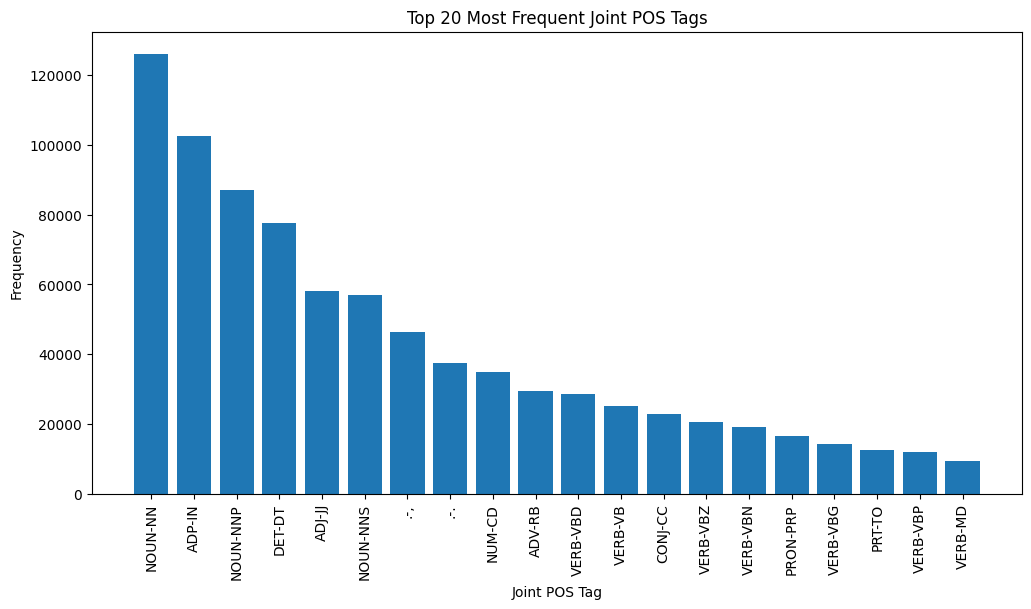

In [ ]:
# ============================================================
# 4.8 Visualize Top 20 Joint POS Tags
# ============================================================

# Get top 20 tags
top_tags = tag_counter.most_common(20)

tags = [item[0] for item in top_tags]
counts = [item[1] for item in top_tags]

# Create figure
plt.figure(figsize=(12,6))

# Plot
plt.bar(tags, counts)

# Labels
plt.title("Top 20 Most Frequent Joint POS Tags")
plt.xlabel("Joint POS Tag")
plt.ylabel("Frequency")

# Rotate labels
plt.xticks(rotation=90)

# Show plot
plt.show()

### Observation

The dataset is highly imbalanced. Certain tags such as NOUN-NN, ADP-IN, and NOUN-NNP appear much more frequently than others. This imbalance motivates the use of macro-averaged metrics in addition to accuracy and micro-averaged scores when evaluating POS tagging models.

## 4.8 Sentence Length Distribution

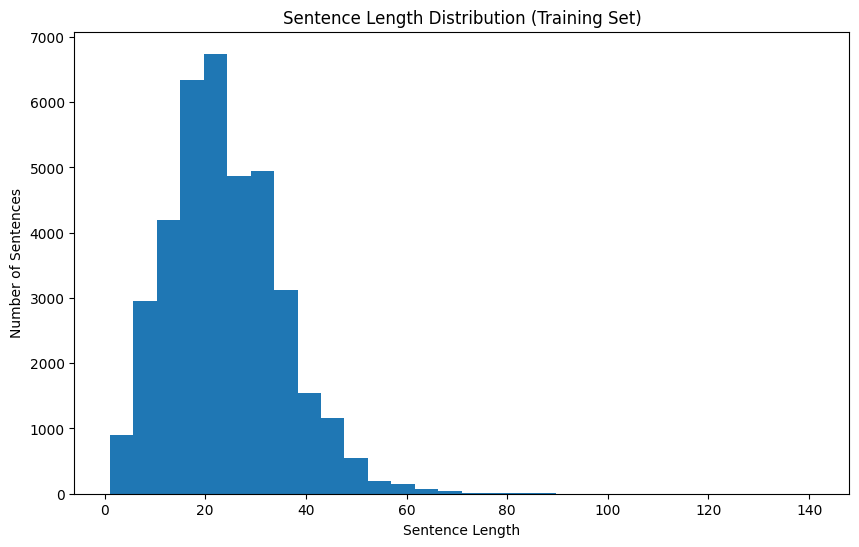

In [ ]:
# ============================================================
# 4.9 Visualize Sentence Length Distribution
# ============================================================

# Create figure
plt.figure(figsize=(10,6))

# Plot histogram
plt.hist(train_lengths, bins=30)

# Labels
plt.title("Sentence Length Distribution (Training Set)")
plt.xlabel("Sentence Length")
plt.ylabel("Number of Sentences")

# Show plot
plt.show()

### Observation

Most sentences are relatively short, with the majority clustered around the average sentence length. A smaller number of sentences are significantly longer, creating a right-skewed distribution. This variation in sentence length is important when designing sequence models such as LSTMs because padding and batching strategies must account for variable-length inputs.

## 4.9 Building Word and Tag Vocabularies

In [ ]:
# ============================================================
# 4.10 Build Word and Tag Vocabularies
# ============================================================

# Special tokens
PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"

# Collect words from the training set only
train_words = []

for sentence in train_sentences:
    for token in sentence:
        train_words.append(token["word"])

# Collect joint POS tags from the training set
train_tags = []

for sentence in train_sentences:
    for token in sentence:
        train_tags.append(token["joint_tag"])

# Create word vocabulary
word_vocab = [PAD_TOKEN, UNK_TOKEN] + sorted(set(train_words))

# Create tag vocabulary
tag_vocab = [PAD_TOKEN] + sorted(set(train_tags))

# Create mapping dictionaries
word_to_idx = {word: idx for idx, word in enumerate(word_vocab)}
idx_to_word = {idx: word for word, idx in word_to_idx.items()}

tag_to_idx = {tag: idx for idx, tag in enumerate(tag_vocab)}
idx_to_tag = {idx: tag for tag, idx in tag_to_idx.items()}

# Print vocabulary information
print("Word Vocabulary Size:", len(word_vocab))
print("Tag Vocabulary Size :", len(tag_vocab))
print("PAD Word Index      :", word_to_idx[PAD_TOKEN])
print("UNK Word Index      :", word_to_idx[UNK_TOKEN])
print("PAD Tag Index       :", tag_to_idx[PAD_TOKEN])

Word Vocabulary Size: 43359
Tag Vocabulary Size : 46
PAD Word Index      : 0
UNK Word Index      : 1
PAD Tag Index       : 0


## 4.10 Converting Sentences and Tags to Indices

In [ ]:
# ============================================================
# 4.11 Convert Words and Tags to Numerical Indices
# ============================================================

def encode_sentences(sentences, word_to_idx, tag_to_idx):
    """
    Converts each sentence from words/tags into word indices and tag indices.
    Unknown words are mapped to the <UNK> token.
    """

    encoded_words = []
    encoded_tags = []

    for sentence in sentences:
        word_indices = []
        tag_indices = []

        for token in sentence:
            word = token["word"]
            tag = token["joint_tag"]

            word_idx = word_to_idx.get(word, word_to_idx[UNK_TOKEN])
            tag_idx = tag_to_idx[tag]

            word_indices.append(word_idx)
            tag_indices.append(tag_idx)

        encoded_words.append(word_indices)
        encoded_tags.append(tag_indices)

    return encoded_words, encoded_tags


# Encode training and development sets
X_train, y_train = encode_sentences(train_sentences, word_to_idx, tag_to_idx)
X_dev, y_dev = encode_sentences(dev_sentences, word_to_idx, tag_to_idx)

# Display one example
print("First sentence words as indices:")
print(X_train[0])

print("\nFirst sentence tags as indices:")
print(y_train[0])

print("\nFirst sentence length:", len(X_train[0]))

First sentence words as indices:
[11315, 19980, 14339, 1405, 37331, 33551, 19248, 17810, 13620, 8, 20542, 7580, 28, 10334, 17812, 31, 19248, 15902, 7714, 17627, 40846, 17167, 29839, 18968, 7687, 35, 8, 12482, 6, 5891, 32, 35, 40846, 37521, 33551, 7447, 35, 34894, 22028, 12031, 7426, 35, 42724, 32525, 20616, 41134, 7634, 10615, 39]

First sentence tags as indices:
[13, 19, 24, 27, 23, 13, 9, 19, 23, 3, 13, 24, 32, 24, 24, 4, 9, 39, 26, 40, 19, 23, 13, 24, 24, 6, 3, 23, 18, 26, 5, 6, 19, 23, 13, 24, 6, 39, 13, 24, 24, 6, 37, 14, 39, 13, 24, 24, 7]

First sentence length: 49


## 4.11 Sequence Length Analysis for Padding

In [ ]:
# ============================================================
# 4.12 Determine Maximum Sequence Length
# ============================================================

# Find maximum sentence length in the training set
max_length_train = max(len(sentence) for sentence in X_train)

# Find maximum sentence length in the development set
max_length_dev = max(len(sentence) for sentence in X_dev)

# Overall maximum length
MAX_LEN = max(max_length_train, max_length_dev)

print("Maximum Training Sentence Length :", max_length_train)
print("Maximum Development Sentence Length :", max_length_dev)
print("Selected Maximum Length :", MAX_LEN)

Maximum Training Sentence Length : 141
Maximum Development Sentence Length : 79
Selected Maximum Length : 141


## 4.12 Padding Sequences

In [ ]:
# ============================================================
# 4.13 Define Padding Function
# ============================================================

def pad_sequences(sequences, max_len, pad_value=0):
    """
    Pads sequences to a fixed length.
    """

    padded_sequences = []

    for sequence in sequences:

        if len(sequence) < max_len:

            sequence = sequence + [pad_value] * (max_len - len(sequence))

        else:

            sequence = sequence[:max_len]

        padded_sequences.append(sequence)

    return padded_sequences

In [ ]:
# ============================================================
# 4.14 Apply Padding to Data
# ============================================================

X_train_padded = pad_sequences(X_train, MAX_LEN)
y_train_padded = pad_sequences(y_train, MAX_LEN)

X_dev_padded = pad_sequences(X_dev, MAX_LEN)
y_dev_padded = pad_sequences(y_dev, MAX_LEN)

print("Training Samples :", len(X_train_padded))
print("Development Samples :", len(X_dev_padded))

print()

print("Length of First Training Sample :", len(X_train_padded[0]))
print("Length of First Development Sample :", len(X_dev_padded[0]))

Training Samples : 37840
Development Samples : 1992

Length of First Training Sample : 141
Length of First Development Sample : 141


# 5. Model

In this project, we compare two different approaches for POS tagging. The first model is a baseline Logistic Regression classifier that predicts the POS tag of each token independently. The second model is a neural sequence model based on Bidirectional LSTM, which uses sentence context when predicting POS tags.

## 5.1 Baseline Model: Logistic Regression

In [ ]:
# ============================================================
# 5.1 Prepare Token-Level Data for Logistic Regression
# ============================================================

# Convert sequence labeling data into token-level classification data
X_train_tokens = []
y_train_tokens = []

for sentence in train_sentences:
    for token in sentence:
        X_train_tokens.append(token["word"])
        y_train_tokens.append(token["joint_tag"])

X_dev_tokens = []
y_dev_tokens = []

for sentence in dev_sentences:
    for token in sentence:
        X_dev_tokens.append(token["word"])
        y_dev_tokens.append(token["joint_tag"])

# Print dataset sizes
print("Training Tokens for Logistic Regression :", len(X_train_tokens))
print("Development Tokens for Logistic Regression :", len(X_dev_tokens))

# Show one example
print("\nExample Token:", X_train_tokens[0])
print("Example Tag  :", y_train_tokens[0])

Training Tokens for Logistic Regression : 902902
Development Tokens for Logistic Regression : 47126

Example Token: In
Example Tag  : ADP-IN


## 5.2 Feature Extraction for Logistic Regression

In [ ]:
# ============================================================
# 5.2 Define Token-Level Features for Logistic Regression
# ============================================================

def token_to_features(word):
    """
    Extracts simple word-level features for a token.
    """

    features = {
        "word.lower": word.lower(),
        "word.is_upper": word.isupper(),
        "word.is_title": word.istitle(),
        "word.is_digit": word.isdigit(),
        "prefix_1": word[:1],
        "prefix_2": word[:2],
        "suffix_1": word[-1:],
        "suffix_2": word[-2:],
        "suffix_3": word[-3:]
    }

    return features


# Convert tokens into feature dictionaries
X_train_features = [token_to_features(word) for word in X_train_tokens]
X_dev_features = [token_to_features(word) for word in X_dev_tokens]

# Show one example
print("Token:", X_train_tokens[0])
print("Features:")
print(X_train_features[0])

Token: In
Features:
{'word.lower': 'in', 'word.is_upper': False, 'word.is_title': True, 'word.is_digit': False, 'prefix_1': 'I', 'prefix_2': 'In', 'suffix_1': 'n', 'suffix_2': 'In', 'suffix_3': 'In'}


## 5.3 Training the Logistic Regression Baseline

In [ ]:
# ============================================================
# 5.3 Train Logistic Regression Baseline Model
# ============================================================

from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Build a pipeline: feature vectorizer + logistic regression classifier
logistic_model = Pipeline([
    ("vectorizer", DictVectorizer(sparse=True)),
    ("classifier", LogisticRegression(
        max_iter=200,
        solver="lbfgs",
        multi_class="auto",
        n_jobs=-1,
        random_state=42
    ))
])

# Train the model
logistic_model.fit(X_train_features, y_train_tokens)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 5.4 Evaluating the Logistic Regression Baseline

In [ ]:
# ============================================================
# 5.4 Generate Predictions Using Logistic Regression
# ============================================================

# Predict tags for training tokens
y_train_pred_logistic = logistic_model.predict(X_train_features)

# Predict tags for development tokens
y_dev_pred_logistic = logistic_model.predict(X_dev_features)

print("Predictions generated successfully.")

Predictions generated successfully.


## 5.5 Logistic Regression Metrics

In [ ]:
# ============================================================
# 5.5 Calculate Accuracy, Micro, and Macro Metrics
# ============================================================

from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# Calculate training accuracy
train_accuracy_logistic = accuracy_score(y_train_tokens, y_train_pred_logistic)

# Calculate development accuracy
dev_accuracy_logistic = accuracy_score(y_dev_tokens, y_dev_pred_logistic)

# Calculate micro-averaged metrics
train_micro_logistic = precision_recall_fscore_support(
    y_train_tokens, y_train_pred_logistic, average="micro", zero_division=0
)

dev_micro_logistic = precision_recall_fscore_support(
    y_dev_tokens, y_dev_pred_logistic, average="micro", zero_division=0
)

# Calculate macro-averaged metrics
train_macro_logistic = precision_recall_fscore_support(
    y_train_tokens, y_train_pred_logistic, average="macro", zero_division=0
)

dev_macro_logistic = precision_recall_fscore_support(
    y_dev_tokens, y_dev_pred_logistic, average="macro", zero_division=0
)

# Display results
print("Logistic Regression - Training Accuracy:", round(train_accuracy_logistic, 4))
print("Logistic Regression - Development Accuracy:", round(dev_accuracy_logistic, 4))

print("\nTraining Micro P/R/F1:", tuple(round(x, 4) for x in train_micro_logistic[:3]))
print("Development Micro P/R/F1:", tuple(round(x, 4) for x in dev_micro_logistic[:3]))

print("\nTraining Macro P/R/F1:", tuple(round(x, 4) for x in train_macro_logistic[:3]))
print("Development Macro P/R/F1:", tuple(round(x, 4) for x in dev_macro_logistic[:3]))

Logistic Regression - Training Accuracy: 0.9306
Logistic Regression - Development Accuracy: 0.9254

Training Micro P/R/F1: (0.9306, 0.9306, 0.9306)
Development Micro P/R/F1: (0.9254, 0.9254, 0.9254)

Training Macro P/R/F1: (0.8357, 0.8231, 0.8215)
Development Macro P/R/F1: (0.8007, 0.8132, 0.7977)


## 5.6 Per-Class Performance Analysis

In [ ]:
# ============================================================
# 5.6 Per-Class Precision, Recall, and F1-Score
# ============================================================

from sklearn.metrics import classification_report

# Generate classification report
report = classification_report(
    y_dev_tokens,
    y_dev_pred_logistic,
    digits=4,
    zero_division=0
)

print(report)

              precision    recall  f1-score   support

         .-#     1.0000    1.0000    1.0000         4
         .-$     1.0000    1.0000    1.0000       351
        .-''     1.0000    0.9668    0.9831       331
         .-(     1.0000    1.0000    1.0000        58
         .-)     1.0000    1.0000    1.0000        62
         .-,     1.0000    1.0000    1.0000      2410
         .-.     1.0000    1.0000    1.0000      1972
         .-:     1.0000    1.0000    1.0000       226
        .-``     1.0000    1.0000    1.0000       344
      ADJ-JJ     0.8857    0.8629    0.8741      2990
     ADJ-JJR     0.7183    0.9273    0.8095       165
     ADJ-JJS     0.8561    0.9826    0.9150       115
      ADP-IN     0.9422    0.9024    0.9219      5347
      ADV-RB     0.9379    0.8463    0.8898      1588
     ADV-RBR     0.7179    0.3146    0.4375        89
     ADV-RBS     0.0000    0.0000    0.0000        15
     ADV-WRB     1.0000    1.0000    1.0000       113
     CONJ-CC     0.9959    

## 5.7 Logistic Regression Results Summary

In [ ]:
# ============================================================
# 5.7 Logistic Regression Results Summary Table
# ============================================================

results_logistic = pd.DataFrame({
    "Dataset": ["Training", "Development"],
    "Accuracy": [
        round(train_accuracy_logistic, 4),
        round(dev_accuracy_logistic, 4)
    ],
    "Micro_F1": [
        round(train_micro_logistic[2], 4),
        round(dev_micro_logistic[2], 4)
    ],
    "Macro_F1": [
        round(train_macro_logistic[2], 4),
        round(dev_macro_logistic[2], 4)
    ]
})

results_logistic

,Dataset,Accuracy,Micro_F1,Macro_F1
0,Training,0.9306,0.9306,0.8215
1,Development,0.9254,0.9254,0.7977


## 5.8 Confusion Matrix

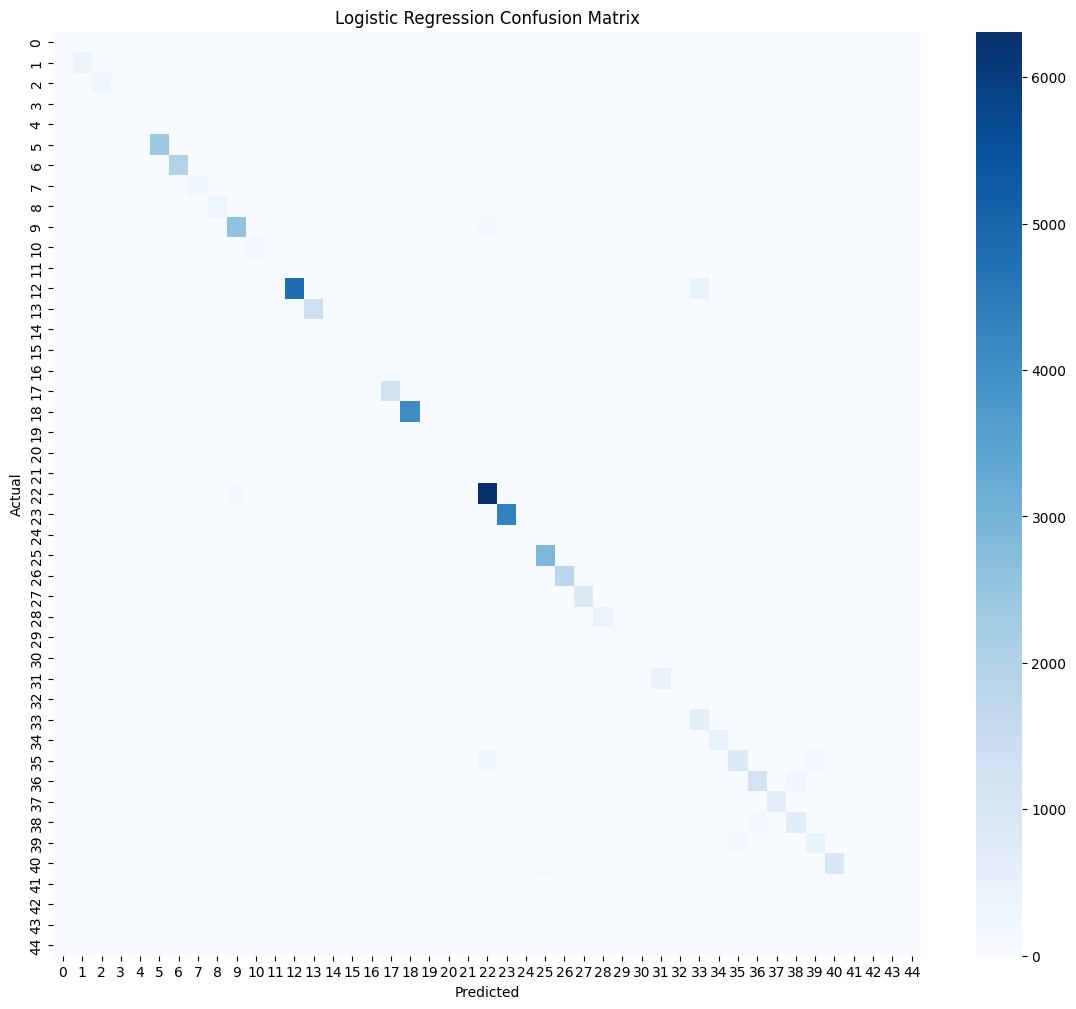

In [ ]:
# ============================================================
# 5.8 Generate Confusion Matrix
# ============================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns

# Build confusion matrix
cm = confusion_matrix(
    y_dev_tokens,
    y_dev_pred_logistic,
    labels=sorted(set(y_dev_tokens))
)

# Plot
plt.figure(figsize=(14,12))
sns.heatmap(cm, cmap="Blues")

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## 5.9 Neural Model: Bidirectional LSTM

In [ ]:
# ============================================================
# 5.9 Import PyTorch Libraries
# ============================================================

import torch
import torch.nn as nn

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

print("PyTorch version:", torch.__version__)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

PyTorch version: 2.10.0+cpu
Device: cpu


## 5.10 Creating PyTorch Dataset

In [ ]:
# ============================================================
# 5.10 Create POS Dataset Class
# ============================================================

class POSDataset(Dataset):

    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.X[idx], dtype=torch.long),
            torch.tensor(self.y[idx], dtype=torch.long)
        )

## 5.11 Building Data Loaders

In [ ]:
# ============================================================
# 5.11 Create Data Loaders
# ============================================================

train_dataset = POSDataset(
    X_train_padded,
    y_train_padded
)

dev_dataset = POSDataset(
    X_dev_padded,
    y_dev_padded
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

dev_loader = DataLoader(
    dev_dataset,
    batch_size=64,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Dev batches:", len(dev_loader))

Train batches: 592
Dev batches: 32


## 5.12 Building the BiLSTM Architecture

In [ ]:
# ============================================================
# 5.12 Define Bidirectional LSTM Model
# ============================================================

class BiLSTMTagger(nn.Module):

    def __init__(
        self,
        vocab_size,
        embedding_dim,
        hidden_dim,
        output_dim,
        pad_idx
    ):

        super().__init__()

        # Embedding layer
        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=pad_idx
        )

        # Bidirectional LSTM layer
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        # Dropout layer
        self.dropout = nn.Dropout(0.3)

        # Fully connected layer
        self.fc = nn.Linear(
            hidden_dim * 2,
            output_dim
        )

    def forward(self, x):

        embedded = self.embedding(x)

        lstm_output, _ = self.lstm(embedded)

        lstm_output = self.dropout(lstm_output)

        predictions = self.fc(lstm_output)

        return predictions

## 5.13 Initializing the BiLSTM Model

In [ ]:
# ============================================================
# 5.13 Initialize BiLSTM Model
# ============================================================

VOCAB_SIZE = len(word_vocab)
OUTPUT_DIM = len(tag_vocab)

EMBEDDING_DIM = 100
HIDDEN_DIM = 128

model = BiLSTMTagger(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    output_dim=OUTPUT_DIM,
    pad_idx=word_to_idx[PAD_TOKEN]
)

model = model.to(device)

print(model)

BiLSTMTagger(
  (embedding): Embedding(43359, 100, padding_idx=0)
  (lstm): LSTM(100, 128, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=46, bias=True)
)


## 5.14 Loss Function and Optimizer

In [ ]:
# ============================================================
# 5.14 Define Loss Function and Optimizer
# ============================================================

# Ignore the padding tag when calculating the loss
criterion = nn.CrossEntropyLoss(
    ignore_index=tag_to_idx[PAD_TOKEN]
)

# Adam optimizer with L2 regularization
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-5
)

print("Loss function and optimizer are ready.")

Loss function and optimizer are ready.


## 5.15 Training and Evaluation Functions

In [ ]:
# ============================================================
# 5.15 Define Training and Evaluation Functions
# ============================================================

def train_one_epoch(model, data_loader, optimizer, criterion, device):
    model.train()

    total_loss = 0

    for words, tags in data_loader:

        words = words.to(device)
        tags = tags.to(device)

        optimizer.zero_grad()

        predictions = model(words)

        predictions = predictions.view(-1, predictions.shape[-1])
        tags = tags.view(-1)

        loss = criterion(predictions, tags)

        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(data_loader)


def evaluate_loss(model, data_loader, criterion, device):
    model.eval()

    total_loss = 0

    with torch.no_grad():

        for words, tags in data_loader:

            words = words.to(device)
            tags = tags.to(device)

            predictions = model(words)

            predictions = predictions.view(-1, predictions.shape[-1])
            tags = tags.view(-1)

            loss = criterion(predictions, tags)

            total_loss += loss.item()

    return total_loss / len(data_loader)

## 5.16 Training the BiLSTM Model

In [ ]:
# ============================================================
# 5.16 Train BiLSTM Model with Early Stopping
# ============================================================

EPOCHS = 5
best_dev_loss = float("inf")
patience = 2
patience_counter = 0

train_losses = []
dev_losses = []

for epoch in range(EPOCHS):

    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        device
    )

    dev_loss = evaluate_loss(
        model,
        dev_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    dev_losses.append(dev_loss)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Training Loss: {train_loss:.4f}")
    print(f"Development Loss: {dev_loss:.4f}")
    print("-" * 40)

    if dev_loss < best_dev_loss:
        best_dev_loss = dev_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_bilstm_model.pt")
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print("Early stopping triggered.")
        break

print("Training completed.")

Epoch 1/5
Training Loss: 0.9369
Development Loss: 0.4148
----------------------------------------
Epoch 2/5
Training Loss: 0.3335
Development Loss: 0.2403
----------------------------------------
Epoch 3/5
Training Loss: 0.2022
Development Loss: 0.1684
----------------------------------------
Epoch 4/5
Training Loss: 0.1376
Development Loss: 0.1413
----------------------------------------
Epoch 5/5
Training Loss: 0.1014
Development Loss: 0.1242
----------------------------------------
Training completed.


## 5.17 BiLSTM Training Curve

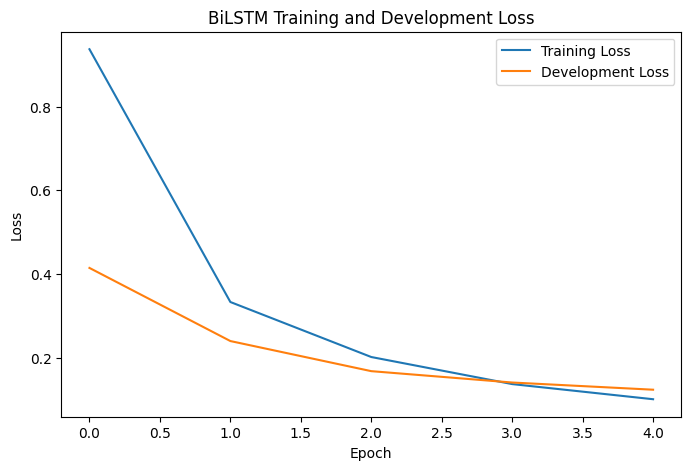

In [ ]:
# ============================================================
# 5.17 Plot Training and Development Loss Curves
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Training Loss")
plt.plot(dev_losses, label="Development Loss")

plt.title("BiLSTM Training and Development Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

## 5.18 Loading the Best BiLSTM Model

In [ ]:
# ============================================================
# 5.18 Load Best Saved BiLSTM Model
# ============================================================

model.load_state_dict(
    torch.load("best_bilstm_model.pt", map_location=device)
)

model = model.to(device)

print("Best BiLSTM model loaded successfully.")

Best BiLSTM model loaded successfully.


## 5.19 Generating BiLSTM Predictions

In [ ]:
# ============================================================
# 5.19 Generate Predictions Using BiLSTM
# ============================================================

model.eval()

all_predictions = []
all_targets = []

with torch.no_grad():

    for words, tags in dev_loader:

        words = words.to(device)

        predictions = model(words)

        predictions = torch.argmax(
            predictions,
            dim=-1
        )

        all_predictions.extend(
            predictions.cpu().numpy().flatten()
        )

        all_targets.extend(
            tags.numpy().flatten()
        )

print("Predictions generated successfully.")

Predictions generated successfully.


## 5.20 Removing Padding Tokens

In [ ]:
# ============================================================
# 5.20 Remove Padding Tokens
# ============================================================

filtered_predictions = []
filtered_targets = []

for pred, target in zip(
    all_predictions,
    all_targets
):

    if target != tag_to_idx[PAD_TOKEN]:

        filtered_predictions.append(pred)
        filtered_targets.append(target)

print("Number of evaluated tokens:", len(filtered_targets))

Number of evaluated tokens: 47126


## 5.21 Converting Indices Back to Tags

In [ ]:
# ============================================================
# 5.21 Convert Predictions Back to POS Tags
# ============================================================

predicted_tags = [
    idx_to_tag[idx]
    for idx in filtered_predictions
]

true_tags = [
    idx_to_tag[idx]
    for idx in filtered_targets
]

print("Sample Prediction :", predicted_tags[0])
print("Sample True Tag   :", true_tags[0])

Sample Prediction : DET-DT
Sample True Tag   : DET-DT


## 5.22 BiLSTM Evaluation Metrics

In [ ]:
# ============================================================
# 5.22 Calculate BiLSTM Evaluation Metrics
# ============================================================

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_recall_fscore_support

# Accuracy
bilstm_accuracy = accuracy_score(
    true_tags,
    predicted_tags
)

# Micro metrics
bilstm_micro = precision_recall_fscore_support(
    true_tags,
    predicted_tags,
    average="micro",
    zero_division=0
)

# Macro metrics
bilstm_macro = precision_recall_fscore_support(
    true_tags,
    predicted_tags,
    average="macro",
    zero_division=0
)

print("BiLSTM Accuracy :", round(bilstm_accuracy, 4))

print("\nBiLSTM Micro P/R/F1:")
print(tuple(round(x, 4) for x in bilstm_micro[:3]))

print("\nBiLSTM Macro P/R/F1:")
print(tuple(round(x, 4) for x in bilstm_macro[:3]))

BiLSTM Accuracy : 0.9614

BiLSTM Micro P/R/F1:
(0.9614, 0.9614, 0.9614)

BiLSTM Macro P/R/F1:
(0.8836, 0.869, 0.8736)


## 5.23 BiLSTM Per-Class Metrics

In [ ]:
# ============================================================
# 5.23 Generate Classification Report for BiLSTM
# ============================================================

from sklearn.metrics import classification_report

bilstm_report = classification_report(
    true_tags,
    predicted_tags,
    digits=4,
    zero_division=0
)

print(bilstm_report)

              precision    recall  f1-score   support

         .-#     1.0000    1.0000    1.0000         4
         .-$     1.0000    0.9972    0.9986       351
        .-''     1.0000    0.9909    0.9954       331
         .-(     1.0000    1.0000    1.0000        58
         .-)     1.0000    1.0000    1.0000        62
         .-,     1.0000    1.0000    1.0000      2410
         .-.     1.0000    1.0000    1.0000      1972
         .-:     1.0000    1.0000    1.0000       226
        .-``     1.0000    1.0000    1.0000       344
      ADJ-JJ     0.8326    0.9385    0.8824      2990
     ADJ-JJR     0.8708    0.9394    0.9038       165
     ADJ-JJS     0.9732    0.9478    0.9604       115
      ADP-IN     0.9853    0.9777    0.9815      5347
      ADV-RB     0.9221    0.9162    0.9191      1588
     ADV-RBR     0.8000    0.6292    0.7044        89
     ADV-RBS     0.8462    0.7333    0.7857        15
     ADV-WRB     1.0000    0.9912    0.9956       113
     CONJ-CC     0.9959    

# 6. Experiments

## 6.1 Model Comparison

In [ ]:
# ============================================================
# 6.1 Compare Logistic Regression and BiLSTM
# ============================================================

comparison_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "BiLSTM"
    ],
    "Accuracy": [
        round(dev_accuracy_logistic, 4),
        round(bilstm_accuracy, 4)
    ],
    "Micro_F1": [
        round(dev_micro_logistic[2], 4),
        round(bilstm_micro[2], 4)
    ],
    "Macro_F1": [
        round(dev_macro_logistic[2], 4),
        round(bilstm_macro[2], 4)
    ]
})

comparison_results

,Model,Accuracy,Micro_F1,Macro_F1
0,Logistic Regression,0.9254,0.9254,0.7977
1,BiLSTM,0.9614,0.9614,0.8736


## 6.2 Model Performance Visualization

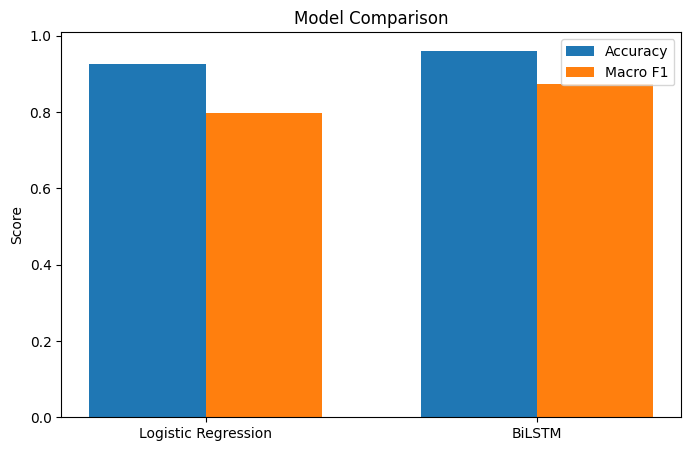

In [ ]:
# ============================================================
# 6.2 Visual Comparison of Models
# ============================================================

models = ["Logistic Regression", "BiLSTM"]

accuracy_scores = [
    dev_accuracy_logistic,
    bilstm_accuracy
]

macro_f1_scores = [
    dev_macro_logistic[2],
    bilstm_macro[2]
]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(
    x - width/2,
    accuracy_scores,
    width,
    label="Accuracy"
)

plt.bar(
    x + width/2,
    macro_f1_scores,
    width,
    label="Macro F1"
)

plt.xticks(x, models)

plt.ylabel("Score")

plt.title("Model Comparison")

plt.legend()

plt.show()

# 7. Results

## 7.1 Final Results Summary

In [ ]:
# ============================================================
# 7.1 Final Results Table
# ============================================================

final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "BiLSTM"
    ],
    "Accuracy": [
        round(dev_accuracy_logistic, 4),
        round(bilstm_accuracy, 4)
    ],
    "Micro_F1": [
        round(dev_micro_logistic[2], 4),
        round(bilstm_micro[2], 4)
    ],
    "Macro_F1": [
        round(dev_macro_logistic[2], 4),
        round(bilstm_macro[2], 4)
    ]
})

final_results

,Model,Accuracy,Micro_F1,Macro_F1
0,Logistic Regression,0.9254,0.9254,0.7977
1,BiLSTM,0.9614,0.9614,0.8736


## 7.2 BiLSTM Confusion Matrix

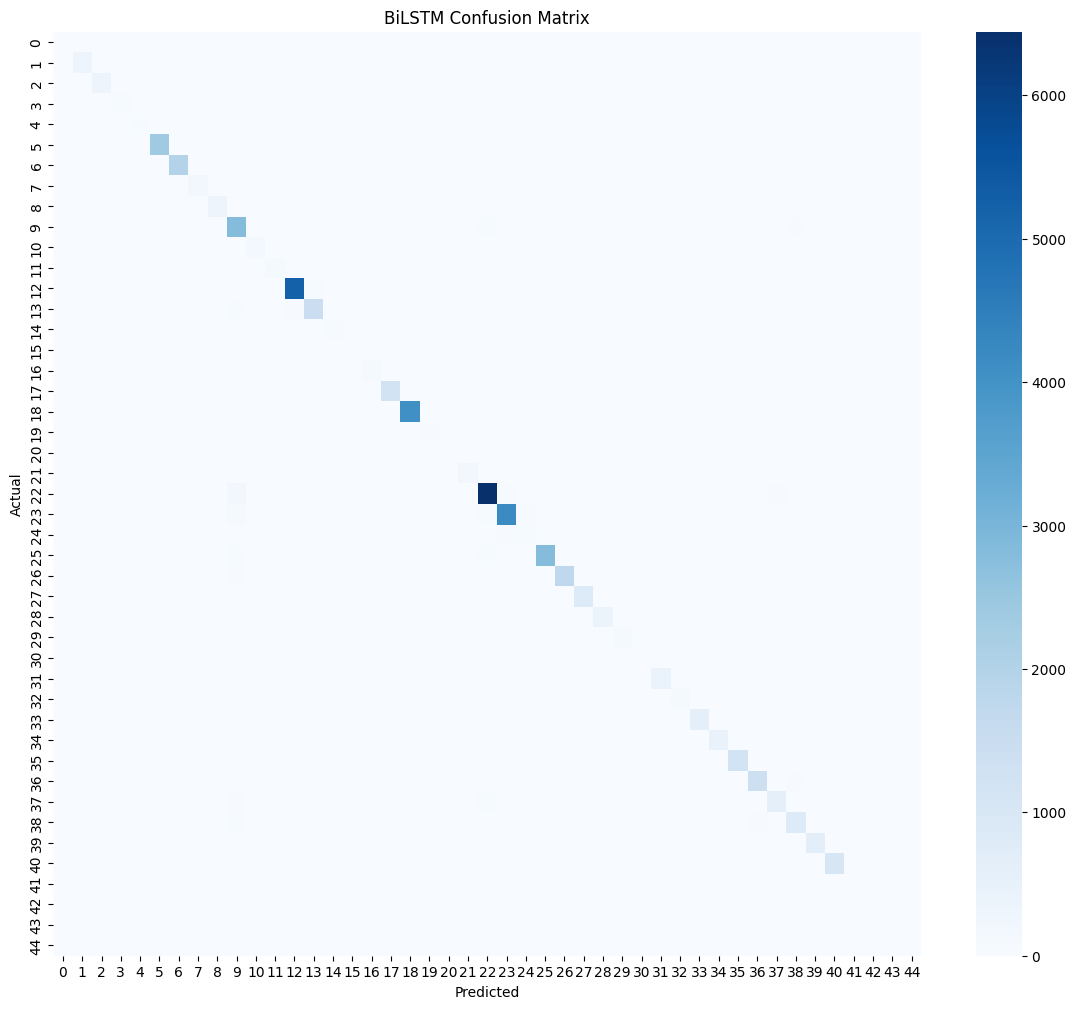

In [ ]:
# ============================================================
# 7.2 Generate BiLSTM Confusion Matrix
# ============================================================

from sklearn.metrics import confusion_matrix

# Build confusion matrix
bilstm_cm = confusion_matrix(
    true_tags,
    predicted_tags,
    labels=sorted(set(true_tags))
)

# Plot confusion matrix
plt.figure(figsize=(14,12))

sns.heatmap(
    bilstm_cm,
    cmap="Blues"
)

plt.title("BiLSTM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## 7.3 Complete Evaluation Metrics

In [ ]:
# ============================================================
# 7.3 Complete Evaluation Metrics Table
# ============================================================

final_metrics = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "BiLSTM"
    ],

    "Accuracy": [
        round(dev_accuracy_logistic, 4),
        round(bilstm_accuracy, 4)
    ],

    "Precision": [
        round(dev_macro_logistic[0], 4),
        round(bilstm_macro[0], 4)
    ],

    "Recall": [
        round(dev_macro_logistic[1], 4),
        round(bilstm_macro[1], 4)
    ],

    "Macro_F1": [
        round(dev_macro_logistic[2], 4),
        round(bilstm_macro[2], 4)
    ]
})

final_metrics

,Model,Accuracy,Precision,Recall,Macro_F1
0,Logistic Regression,0.9254,0.8007,0.8132,0.7977
1,BiLSTM,0.9614,0.8836,0.8690,0.8736


## 7.4 Performance Improvement

In [ ]:
# ============================================================
# 7.4 Calculate Improvement Over Baseline
# ============================================================

accuracy_improvement = (
    bilstm_accuracy - dev_accuracy_logistic
)

macro_f1_improvement = (
    bilstm_macro[2] - dev_macro_logistic[2]
)

print(
    "Accuracy Improvement:",
    round(accuracy_improvement, 4)
)

print(
    "Macro F1 Improvement:",
    round(macro_f1_improvement, 4)
)

Accuracy Improvement: 0.036
Macro F1 Improvement: 0.0759


## 7.5 BiLSTM Training Set Evaluation

In [ ]:
# ============================================================
# 7.5 Evaluate BiLSTM on Training Set
# ============================================================

model.eval()

train_predictions = []
train_targets = []

with torch.no_grad():

    for words, tags in train_loader:

        words = words.to(device)

        predictions = model(words)

        predictions = torch.argmax(
            predictions,
            dim=-1
        )

        train_predictions.extend(
            predictions.cpu().numpy().flatten()
        )

        train_targets.extend(
            tags.numpy().flatten()
        )

filtered_train_predictions = []
filtered_train_targets = []

for pred, target in zip(
    train_predictions,
    train_targets
):

    if target != tag_to_idx[PAD_TOKEN]:

        filtered_train_predictions.append(pred)
        filtered_train_targets.append(target)

train_pred_tags = [
    idx_to_tag[idx]
    for idx in filtered_train_predictions
]

train_true_tags = [
    idx_to_tag[idx]
    for idx in filtered_train_targets
]

train_accuracy_bilstm = accuracy_score(
    train_true_tags,
    train_pred_tags
)

train_micro_bilstm = precision_recall_fscore_support(
    train_true_tags,
    train_pred_tags,
    average="micro",
    zero_division=0
)

train_macro_bilstm = precision_recall_fscore_support(
    train_true_tags,
    train_pred_tags,
    average="macro",
    zero_division=0
)

print("BiLSTM Training Accuracy :", round(train_accuracy_bilstm,4))

print("\nBiLSTM Training Micro F1:")
print(tuple(round(x,4) for x in train_micro_bilstm[:3]))

print("\nBiLSTM Training Macro F1:")
print(tuple(round(x,4) for x in train_macro_bilstm[:3]))

BiLSTM Training Accuracy : 0.9781

BiLSTM Training Micro F1:
(0.9781, 0.9781, 0.9781)

BiLSTM Training Macro F1:
(0.9207, 0.8835, 0.8907)


## 7.6 Final Training and Development Results


In [ ]:
# ============================================================
# 7.6 Final Training and Development Results Table
# ============================================================

complete_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Logistic Regression",
        "BiLSTM",
        "BiLSTM"
    ],

    "Dataset": [
        "Training",
        "Development",
        "Training",
        "Development"
    ],

    "Accuracy": [
        round(train_accuracy_logistic, 4),
        round(dev_accuracy_logistic, 4),
        round(train_accuracy_bilstm, 4),
        round(bilstm_accuracy, 4)
    ],

    "Micro_F1": [
        round(train_micro_logistic[2], 4),
        round(dev_micro_logistic[2], 4),
        round(train_micro_bilstm[2], 4),
        round(bilstm_micro[2], 4)
    ],

    "Macro_F1": [
        round(train_macro_logistic[2], 4),
        round(dev_macro_logistic[2], 4),
        round(train_macro_bilstm[2], 4),
        round(bilstm_macro[2], 4)
    ]
})

complete_results

,Model,Dataset,Accuracy,Micro_F1,Macro_F1
0,Logistic Regression,Training,0.9306,0.9306,0.8215
1,Logistic Regression,Development,0.9254,0.9254,0.7977
2,BiLSTM,Training,0.9781,0.9781,0.8907
3,BiLSTM,Development,0.9614,0.9614,0.8736


# 8. Analysis & Conclusion

## 8.1 Error Analysis

The results show that the BiLSTM model significantly outperformed the Logistic Regression baseline. The BiLSTM achieved higher accuracy, precision, recall, and F1-score across most POS categories. This improvement is mainly due to the ability of the BiLSTM to capture contextual information from surrounding words, while Logistic Regression predicts each token independently.

The largest performance gains were observed for several verb and adjective categories. However, rare classes such as X-FW, X-LS, and X-UH remained challenging due to the limited number of training examples available for these tags.

The difference between Macro F1 and Accuracy indicates that class imbalance remains an important challenge in the dataset.

## 8.2 Conclusion

In this project, we developed and evaluated two POS tagging models using the English Penn Treebank corpus. A Logistic Regression classifier was implemented as a baseline model and compared against a Bidirectional LSTM neural network.

Experimental results showed that the BiLSTM model achieved the best overall performance, reaching an accuracy of 96.14% and a Macro F1-score of 87.36% on the development set. The results demonstrate the effectiveness of neural sequence models for POS tagging tasks and highlight the importance of contextual information when predicting grammatical categories.

Future work may explore more advanced architectures such as BiLSTM-CRF models, attention mechanisms, and transformer-based approaches.

# 9. AI Usage Statement

During this project, AI tools were used only as supporting tools for understanding concepts, debugging code, improving notebook organization, and reviewing explanations.

AI assistance was used for:
- Understanding NLP concepts and POS tagging methodologies.
- Debugging programming errors and implementation issues.
- Reviewing notebook structure and organization.
- Generating boilerplate code examples that were reviewed, modified, and validated by the team.

All model implementation, experiments, training procedures, evaluation results, analysis, and conclusions were reviewed and verified by the project team. The team is responsible for all code, results, and interpretations presented in this notebook.

# 10. References

[1] Huang, Z., Xu, W., and Yu, K. (2015). Bidirectional LSTM-CRF Models for Sequence Tagging.

[2] Universal Dependencies Project. English Penn Treebank Dataset.

[3] Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python. Journal of Machine Learning Research.

[4] Paszke, A., et al. (2019). PyTorch: An Imperative Style, High-Performance Deep Learning Library.

[5] Jurafsky, D. and Martin, J. H. Speech and Language Processing.